Sampling rate: 2 Hz
f(t) = 0.3 sin(2π · 1 · t) - 0.3 sin(2π · 2 · t) + 0.2 sin(2π · 3 · t) + 0.1 sin(2π · 4 · t) - 0.1 sin(2π · 5 · t)
g(t) = 0.4 sin(2π · 1 · t)


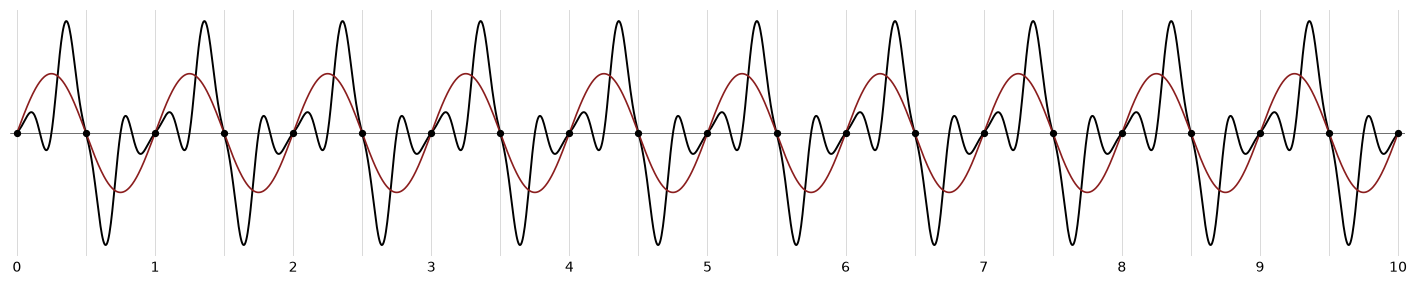

Sampling rate: 4 Hz
f(t) = 0.3 sin(2π · 1 · t) - 0.3 sin(2π · 2 · t) + 0.2 sin(2π · 3 · t) + 0.1 sin(2π · 4 · t) - 0.1 sin(2π · 5 · t)
g(t) = - 0.3 sin(2π · 2 · t)


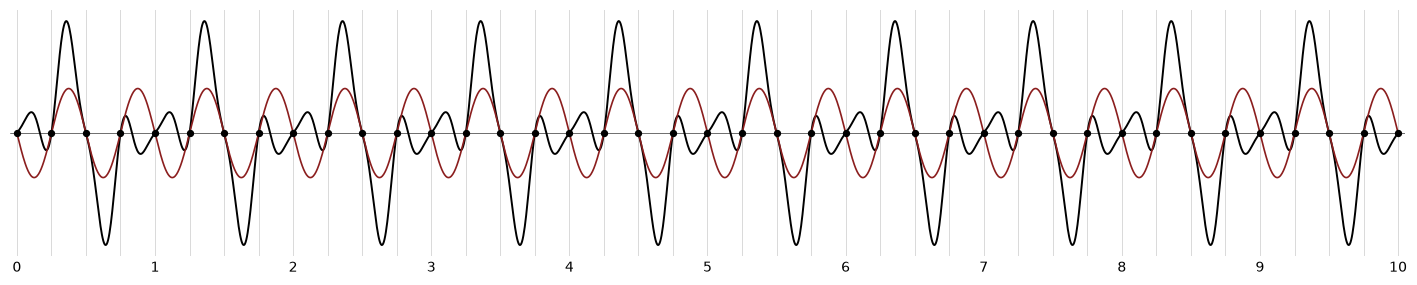

Sampling rate: 6 Hz
f(t) = 0.3 sin(2π · 1 · t) - 0.3 sin(2π · 2 · t) + 0.2 sin(2π · 3 · t) + 0.1 sin(2π · 4 · t) - 0.1 sin(2π · 5 · t)
g(t) = 0.4 sin(2π · 1 · t) - 0.4 sin(2π · 2 · t) + 0.2 sin(2π · 3 · t)


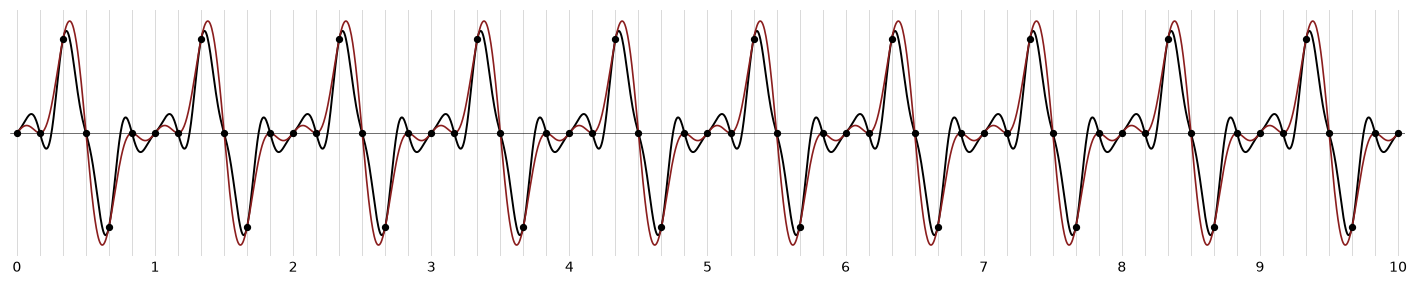

Sampling rate: 8 Hz
f(t) = 0.3 sin(2π · 1 · t) - 0.3 sin(2π · 2 · t) + 0.2 sin(2π · 3 · t) + 0.1 sin(2π · 4 · t) - 0.1 sin(2π · 5 · t)
g(t) = 0.3 sin(2π · 1 · t) - 0.3 sin(2π · 2 · t) + 0.3 sin(2π · 3 · t) + 0.1 sin(2π · 4 · t)


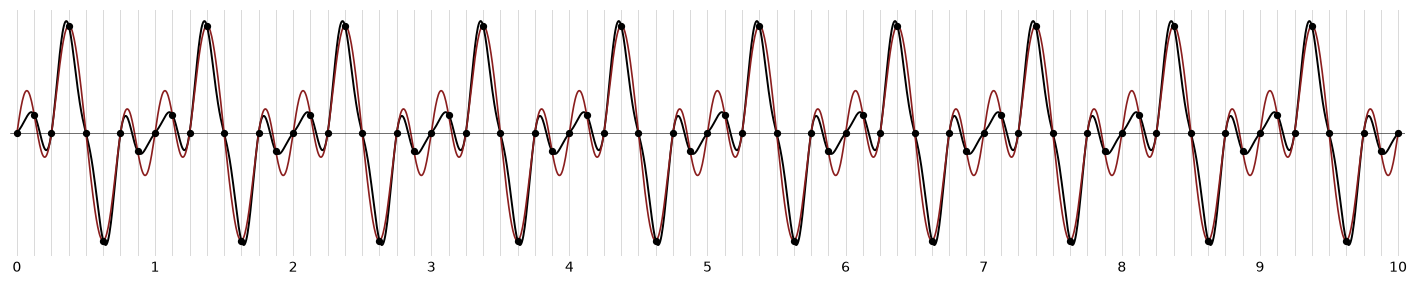

Sampling rate: 10 Hz
f(t) = 0.3 sin(2π · 1 · t) - 0.3 sin(2π · 2 · t) + 0.2 sin(2π · 3 · t) + 0.1 sin(2π · 4 · t) - 0.1 sin(2π · 5 · t)
g(t) = f(t)


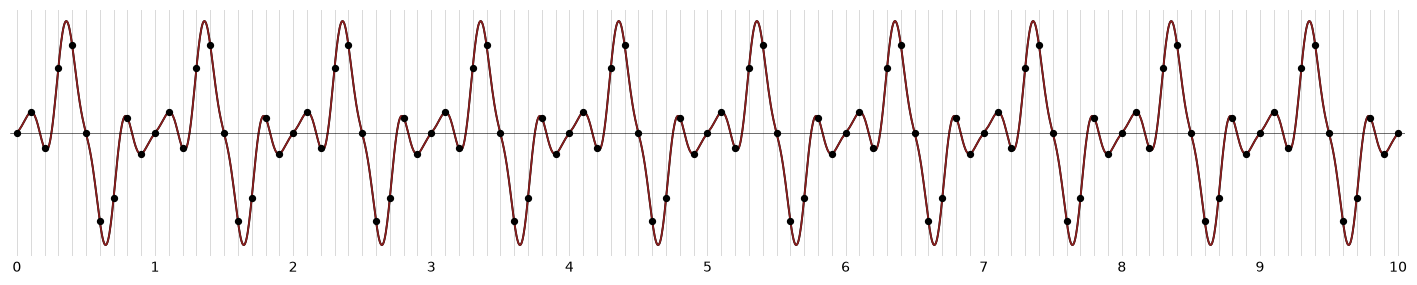

Wrote formula data to /home/dito/dev/monorepo/writing/graphics/chapters/aliasing/assets/sampling-formulas.json


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

COMPONENTS = (
    (0.3, 1),
    (-0.3, 2),
    (0.2, 3),
    (0.1, 4),
    (-0.1, 5),
)

def f(t):
    return sum(
        amplitude * np.sin(2 * np.pi * frequency * t)
        for amplitude, frequency in COMPONENTS
    )

def lowest_alias(frequency, sampling_rate):
    if sampling_rate <= 0:
        raise ValueError("sampling_rate must be positive")

    # Frequencies separated by an integer multiple of the sampling rate
    # have identical values at the sample times. Fold into the Nyquist
    # interval to choose the representative with the lowest magnitude.
    alias = (frequency + sampling_rate / 2) % sampling_rate - sampling_rate / 2

    # Both signs are valid exactly at Nyquist. Keep the source sign so the
    # 10 Hz candidate overlays the 5 Hz source component exactly.
    if np.isclose(alias, -sampling_rate / 2):
        return np.copysign(sampling_rate / 2, frequency)
    return alias

def lower_frequency_candidate(t, sampling_rate):
    return sum(
        amplitude * np.sin(
            2 * np.pi * lowest_alias(frequency, sampling_rate) * t
        )
        for amplitude, frequency in COMPONENTS
    )

def format_formula(name, components):
    terms = []
    for index, (amplitude, frequency) in enumerate(components):
        sign = "-" if amplitude < 0 else "+"
        term = f"{abs(amplitude):g} sin(2π · {frequency:g} · t)"
        if index == 0:
            terms.append(f"- {term}" if amplitude < 0 else term)
        else:
            terms.append(f"{sign} {term}")
    return f"{name}(t) = {' '.join(terms)}"

def simplify_components(components):
    combined = {}
    for amplitude, frequency in components:
        if np.isclose(frequency, 0):
            continue
        if frequency < 0:
            amplitude = -amplitude
            frequency = -frequency
        frequency = round(float(frequency), 12)
        combined[frequency] = combined.get(frequency, 0) + amplitude

    return tuple(
        (amplitude, frequency)
        for frequency, amplitude in sorted(combined.items())
        if not np.isclose(amplitude, 0)
    )

def find_output_directory():
    for directory in (Path.cwd(), *Path.cwd().parents):
        output_directory = (
            directory / "writing/graphics/chapters/aliasing/assets"
        )
        if output_directory.parent.exists():
            return output_directory
    raise FileNotFoundError("Could not find the graphics book directory")

def component_records(components):
    return [
        {"amplitude": float(amplitude), "frequency_hz": float(frequency)}
        for amplitude, frequency in components
    ]

def plot_sampling_rate(sampling_rate):
    t = np.linspace(0, DURATION, 2000)
    sample_count = int(np.floor(DURATION * sampling_rate + 1e-12)) + 1
    sample_times = np.arange(sample_count) / sampling_rate
    original_samples = f(sample_times)
    candidate_samples = lower_frequency_candidate(sample_times, sampling_rate)

    # The aliased candidate must pass through every original sample.
    assert np.allclose(candidate_samples, original_samples, atol=1e-10)

    fig, ax = plt.subplots(figsize=(18, 3.2))
    ax.plot(t, f(t), color="black", linewidth=1.4)
    ax.plot(
        t,
        lower_frequency_candidate(t, sampling_rate),
        color="#8b1e1e",
        linewidth=1.2,
    )

    for sample_time in sample_times:
        ax.axvline(sample_time, color="0.85", linewidth=0.7, zorder=0)

    ax.scatter(
        sample_times,
        original_samples,
        color="black",
        s=18,
        zorder=10,
    )

    ax.axhline(0, color="black", linewidth=0.4)
    ax.set_xlim(-0.05, DURATION + 0.05)
    ax.set_xticks(np.arange(0, DURATION + 1, 1))
    ax.tick_params(axis="x", length=0)
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    return fig

DURATION = 10
EXPORT_SAMPLE_RATES = (2, 4, 6, 8, 10)
OUTPUT_DIRECTORY = find_output_directory()
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

formula_data = {
    "duration_seconds": DURATION,
    "source": {
        "symbol": "f",
        "components": component_records(COMPONENTS),
        "display": format_formula("f", COMPONENTS),
    },
    "samples": [],
}

for sampling_rate in EXPORT_SAMPLE_RATES:
    alias_components = simplify_components(
        (
            (amplitude, lowest_alias(frequency, sampling_rate))
            for amplitude, frequency in COMPONENTS
        )
    )
    image_name = f"sampling-rate-{sampling_rate}-hz.png"
    candidate_display = (
        "g(t) = f(t)"
        if sampling_rate == 10
        else format_formula("g", alias_components)
    )

    print(f"Sampling rate: {sampling_rate:g} Hz")
    print(format_formula("f", COMPONENTS))
    print(candidate_display)

    fig = plot_sampling_rate(sampling_rate)
    fig.savefig(
        OUTPUT_DIRECTORY / image_name,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.03,
    )
    plt.show()

    formula_data["samples"].append({
        "sampling_rate_hz": sampling_rate,
        "image": image_name,
        "candidate": {
            "symbol": "g",
            "components": component_records(alias_components),
            "display": candidate_display,
        },
    })

formula_path = OUTPUT_DIRECTORY / "sampling-formulas.json"
formula_path.write_text(json.dumps(formula_data, indent=2) + "\n")
print(f"Wrote formula data to {formula_path}")